# **Section 9: Nested Cross-Validation and Final Model Validation**

This notebook implements **nested cross-validation** to estimate the performance of the best 3 models.

**Nested CV Structure:**
- **Outer loop (5-fold):** Estimates true model performance
- **Inner loop (5-fold):** Hyperparameter tuning via GridSearchCV

**Models evaluated:**
1. Logistic Regression
2. Support Vector Machine
3. K-Nearest Neighbours

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (12, 8)

## **1. Load Data**

In [2]:
# Load features and labels
cnv_data = pd.read_csv('cnvs_cleaned_SXT.csv', index_col=0)
profiles = pd.read_csv('SXT.csv', index_col=0)

X = cnv_data.values
y = profiles.values

print(f"Data shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Categories: {np.unique(y)}")

Data shape: (221, 7197)
Label shape: (221, 1)
Categories: [0 1]


## **2. Nested Cross-Validation**

### **2.1 Nested CV Function**

In [3]:
def nested_cross_validation(model_name, pipeline, param_grid, X, y, cv_outer=5, cv_inner=5):
    """
    Perform nested cross-validation for model evaluation.
    Returns a dictionary with nested CV results
    """
    
    # Setup outer cross-validation
    cv_outer_splitter = StratifiedKFold(n_splits=cv_outer, shuffle=True, random_state=42)
    
    # Store results for each outer fold
    outer_accuracies = []
    outer_aucs = []
    best_params_list = []
    
    fold = 1
    for train_idx, test_idx in cv_outer_splitter.split(X, y):
        # Split data
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Inner cross-validation (hyperparameter tuning)
        grid_search = GridSearchCV(
            pipeline,
            param_grid,
            cv=StratifiedKFold(n_splits=cv_inner, shuffle=True, random_state=42),
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
        
        # Fit on training data
        grid_search.fit(X_train, y_train)
        
        # Evaluate on test data
        y_pred = grid_search.predict(X_test)
        y_proba = grid_search.predict_proba(X_test)[:, 1]
        
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        
        outer_accuracies.append(accuracy)
        outer_aucs.append(auc)
        best_params_list.append(grid_search.best_params_)
        
        print(f'{model_name}, Fold {fold}: Accuracy={accuracy:.4f}, AUC={auc:.4f}')
        fold += 1
    
    # Return summary statistics
    results = {
        'model_name': model_name,
        'accuracies': np.array(outer_accuracies),
        'aucs': np.array(outer_aucs),
        'accuracy_mean': np.mean(outer_accuracies),
        'accuracy_std': np.std(outer_accuracies),
        'accuracy_ci': 1.96 * np.std(outer_accuracies) / np.sqrt(cv_outer),
        'auc_mean': np.mean(outer_aucs),
        'auc_std': np.std(outer_aucs),
        'auc_ci': 1.96 * np.std(outer_aucs) / np.sqrt(cv_outer),
        'best_params_list': best_params_list
    }
    
    return results

### **2.2 Define Models and Hyperparameter Grids**

In [4]:
# Define pipelines and hyperparameter grids

# Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=2, penalty="elasticnet", solver="saga"))
])

lr_param_grid = {
    'logreg__C': np.logspace(-1, 3, 6)
}

# Support Vector Machine
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=2))
])

svm_param_grid = {
    'svm__kernel': ['linear', 'rbf'],
    'svm__C': [0.1, 1, 10]
}

# KNN
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

knn_param_grid = {
    'knn__n_neighbors': [1, 5, 10, 15, 20, 30, 35, 40]
}

### **2.3 Run Nested Cross-Validation**

In [5]:
results_lr = nested_cross_validation(
    'Logistic Regression',
    lr_pipeline,
    lr_param_grid,
    X, y
)
print()

results_svm = nested_cross_validation(
    'SVM',
    svm_pipeline,
    svm_param_grid,
    X, y
)
print()

results_knn = nested_cross_validation(
    'KNN',
    knn_pipeline,
    knn_param_grid,
    X, y
)
print()

Logistic Regression, Fold 1: Accuracy=1.0000, AUC=1.0000
Logistic Regression, Fold 2: Accuracy=0.9318, AUC=0.9833
Logistic Regression, Fold 3: Accuracy=0.9545, AUC=0.9688
Logistic Regression, Fold 4: Accuracy=0.9318, AUC=1.0000
Logistic Regression, Fold 5: Accuracy=0.9545, AUC=0.9959

SVM, Fold 1: Accuracy=1.0000, AUC=1.0000
SVM, Fold 2: Accuracy=0.9091, AUC=0.9771
SVM, Fold 3: Accuracy=0.9545, AUC=0.9708
SVM, Fold 4: Accuracy=0.9318, AUC=1.0000
SVM, Fold 5: Accuracy=0.9773, AUC=0.9959

KNN, Fold 1: Accuracy=0.9333, AUC=0.9931
KNN, Fold 2: Accuracy=0.9545, AUC=0.9583
KNN, Fold 3: Accuracy=0.9091, AUC=0.9708
KNN, Fold 4: Accuracy=0.9091, AUC=0.9042
KNN, Fold 5: Accuracy=0.9318, AUC=0.9306



## **3. Results Summary**

In [6]:
# Compile results
all_results = [results_lr, results_svm, results_knn]

# Create summary dataframe
summary_data = []
for res in all_results:
    summary_data.append({
        'Model': res['model_name'],
        'Accuracy': f"{res['accuracy_mean']:.4f} ± {res['accuracy_std']:.4f}",
        'Accuracy (95% CI)': f"[{res['accuracy_mean']-res['accuracy_ci']:.4f}, {res['accuracy_mean']+res['accuracy_ci']:.4f}]",
        'AUC': f"{res['auc_mean']:.4f} ± {res['auc_std']:.4f}",
        'AUC (95% CI)': f"[{res['auc_mean']-res['auc_ci']:.4f}, {res['auc_mean']+res['auc_ci']:.4f}]"
    })

summary_df = pd.DataFrame(summary_data)
print('\nNested Cross-Validation Summary:')
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('nested_cv_results.csv', index=False)
print('\nResults saved to nested_cv_results.csv')


Nested Cross-Validation Summary:
              Model        Accuracy Accuracy (95% CI)             AUC     AUC (95% CI)
Logistic Regression 0.9545 ± 0.0249  [0.9327, 0.9764] 0.9896 ± 0.0121 [0.9790, 1.0002]
                SVM 0.9545 ± 0.0321  [0.9264, 0.9827] 0.9888 ± 0.0123 [0.9779, 0.9996]
                KNN 0.9276 ± 0.0171  [0.9126, 0.9426] 0.9514 ± 0.0311 [0.9242, 0.9786]

Results saved to nested_cv_results.csv


## **4. Visualizations**

### **4.1 Accuracy Comparison**

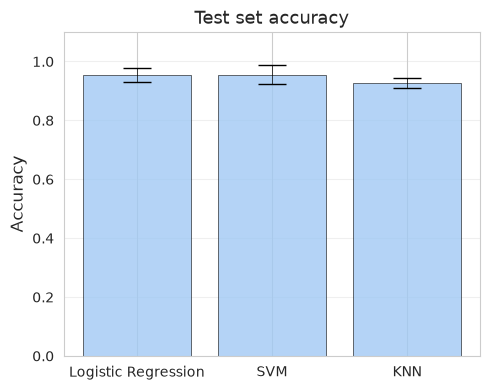

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))

models = [res['model_name'] for res in all_results]
accuracies = [res['accuracy_mean'] for res in all_results]
stds = [res['accuracy_std'] for res in all_results]
bars = ax.bar(models, accuracies, yerr=stds, capsize=10, alpha=0.8, edgecolor='black', linewidth=0.5, error_kw={'linewidth': 0.5})

ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Test set accuracy", fontsize=13)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/09_nested_cv_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

### **4.2 AUC Comparison**

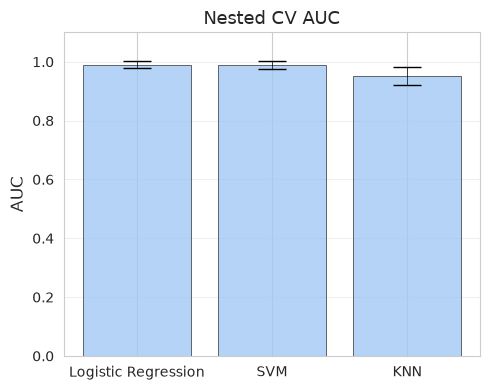

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))

aucs = [res['auc_mean'] for res in all_results]
auc_stds = [res['auc_std'] for res in all_results]

bars = ax.bar(models, aucs, yerr=auc_stds, capsize=10, alpha=0.8, edgecolor='black', linewidth=0.5, error_kw={'linewidth': 0.5})

ax.set_ylabel("AUC", fontsize=12)
ax.set_title("Nested CV AUC", fontsize=13)
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/09_nested_cv_auc.png", dpi=300, bbox_inches='tight')
plt.show()

### **4.3 Fold-by-Fold Accuracy**

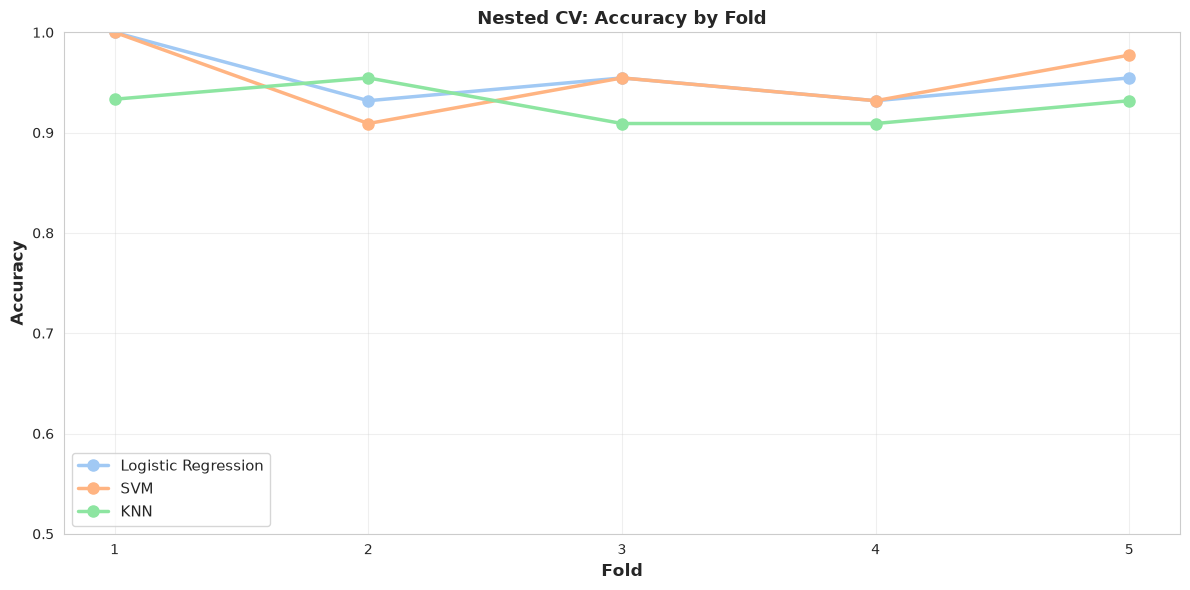

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

folds = np.arange(1, 6)
for i, res in enumerate(all_results):
    ax.plot(folds, res['accuracies'], 'o-', linewidth=2.5, markersize=8,
            label=res['model_name'])

ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Nested CV: Accuracy by Fold', fontsize=13, fontweight='bold')
ax.set_xticks(folds)
ax.set_ylim([0.5, 1.0])
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("Figures/09_nested_cv_folds.png", dpi=300, bbox_inches='tight')
plt.show()

## **5. Conclusions**

In [10]:
# Rank models by accuracy
ranked = sorted(all_results, key=lambda x: x['accuracy_mean'], reverse=True)

print('\nModel Rankings (by Accuracy):')
for i, res in enumerate(ranked, 1):
    print(f"{i}. {res['model_name']:25s} {res['accuracy_mean']:.3f} ± {res['accuracy_std']:.3f}")

print(f"\nBest model: {ranked[0]['model_name']}")
print(f"Mean accuracy: {ranked[0]['accuracy_mean']:.3f}")
print(f"std: {ranked[0]['accuracy_std']:.3f}")



Model Rankings (by Accuracy):
1. Logistic Regression       0.955 ± 0.025
2. SVM                       0.955 ± 0.032
3. KNN                       0.928 ± 0.017

Best model: Logistic Regression
Mean accuracy: 0.955
std: 0.025
